# İstatistiksel Analiz
**Kutay Kalay** · SoftITo Yapay Zeka · 18.09.2026

Bir online eğitim platformunun 1200 kullanıcısına ait sentetik veri üzerinde
betimsel istatistik, hipotez testleri, korelasyon, çoklu doğrusal bağlantı, regresyon ve PCA uyguluyorum.

**Hipotez testlerinde genel kural:** p < 0.05 ise H0 (fark/ilişki yok) reddedilir.

## 0. Kütüphaneler ve Veri

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="ticks", palette="deep")
pd.set_option("display.float_format", "{:.3f}".format)
rng = np.random.default_rng(2026)

Değişkenler:
- `yas`, `haftalik_saat` (platformda geçirilen süre), `tamamlanan_kurs`, `sinav_puani`, `aylik_odeme`
- `paket` (Temel / Plus / Pro), `cihaz` (Mobil / Masaüstü), `sertifika_aldi` (0/1)

Değişkenler arasında bilerek ilişki kurdum: çalışma süresi ve paket, sınav puanını etkiliyor.

In [2]:
N = 1200

paket = rng.choice(["Temel", "Plus", "Pro"], N, p=[0.5, 0.3, 0.2])
paket_etkisi = pd.Series(paket).map({"Temel": 0, "Plus": 4, "Pro": 8}).to_numpy()

yas = rng.normal(29, 7, N).clip(17, 65).round()
haftalik_saat = rng.gamma(shape=2.2, scale=3.0, size=N).round(1)          # sağa çarpık
tamamlanan_kurs = (haftalik_saat * 0.35 + rng.poisson(1.5, N)).round()     # saat ile güçlü ilişki
sinav_puani = (48 + 1.6 * haftalik_saat + paket_etkisi + rng.normal(0, 9, N)).clip(0, 100).round(1)
aylik_odeme = (pd.Series(paket).map({"Temel": 149, "Plus": 249, "Pro": 399}).to_numpy()
               + rng.normal(0, 15, N)).round(2)
cihaz = rng.choice(["Mobil", "Masaüstü"], N, p=[0.6, 0.4])

sertifika_olasiligi = 1 / (1 + np.exp(-(sinav_puani - 70) / 6))
sertifika_aldi = rng.binomial(1, sertifika_olasiligi)

df = pd.DataFrame({
    "yas": yas, "haftalik_saat": haftalik_saat, "tamamlanan_kurs": tamamlanan_kurs,
    "sinav_puani": sinav_puani, "aylik_odeme": aylik_odeme,
    "paket": paket, "cihaz": cihaz, "sertifika_aldi": sertifika_aldi,
})

# biraz eksik değer
for col, adet in [("yas", 25), ("haftalik_saat", 30), ("sinav_puani", 20)]:
    df.loc[rng.choice(df.index, adet, replace=False), col] = np.nan

sayisal = ["yas", "haftalik_saat", "tamamlanan_kurs", "sinav_puani", "aylik_odeme"]
df.head()

,yas,haftalik_saat,tamamlanan_kurs,sinav_puani,aylik_odeme,paket,cihaz,sertifika_aldi
0,26.000,8.900,5.000,74.300,148.490,Temel,Mobil,1
1,25.000,11.500,6.000,68.800,258.050,Plus,Mobil,0
2,18.000,1.000,3.000,42.700,151.710,Temel,Masaüstü,0
3,26.000,16.200,7.000,67.000,149.350,Temel,Mobil,0
4,32.000,3.600,2.000,57.300,168.660,Temel,Masaüstü,0


## 1. Genel Bakış

In [3]:
pd.DataFrame({
    "tip": df.dtypes,
    "benzersiz": df.nunique(),
    "eksik": df.isna().sum(),
    "eksik_%": df.isna().mean() * 100,
})

,tip,benzersiz,eksik,eksik_%
yas,float64,35,25,2.083
haftalik_saat,float64,187,30,2.500
tamamlanan_kurs,float64,14,0,0.000
sinav_puani,float64,438,20,1.667
aylik_odeme,float64,1140,0,0.000
paket,object,3,0,0.000
cihaz,object,2,0,0.000
sertifika_aldi,int64,2,0,0.000


In [4]:
print("Tekrar eden satır:", df.duplicated().sum())

Tekrar eden satır: 0


## 2. Betimsel İstatistik ve Güven Aralığı
Örneklem ortalaması, gerçek (popülasyon) ortalamasının tam kendisi değildir.
**%95 güven aralığı**: aynı yöntemle 100 kez örneklem alsak, bunların ~95'inde hesaplanan aralık gerçek ortalamayı içerir.

Formül: `ortalama ± t_kritik × (s / √n)`

In [5]:
def guven_araligi(seri, guven=0.95):
    x = seri.dropna()
    n = len(x)
    ort = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    t = stats.t.ppf((1 + guven) / 2, df=n - 1)
    return ort, ort - t * se, ort + t * se

ga = pd.DataFrame(
    [guven_araligi(df[c]) for c in sayisal],
    index=sayisal, columns=["ortalama", "alt_%95", "ust_%95"],
)
ga

,ortalama,alt_%95,ust_%95
yas,28.727,28.343,29.111
haftalik_saat,6.699,6.442,6.957
tamamlanan_kurs,3.873,3.757,3.990
sinav_puani,61.465,60.799,62.132
aylik_odeme,232.891,227.446,238.336


In [6]:
betimsel = df[sayisal].describe().T
betimsel["carpiklik"] = df[sayisal].skew()
betimsel["basiklik"] = df[sayisal].kurt()
betimsel

,count,mean,std,min,25%,50%,75%,max,carpiklik,basiklik
yas,1175.000,28.727,6.709,17.000,24.000,29.000,33.000,52.000,0.249,-0.336
haftalik_saat,1170.000,6.699,4.488,0.300,3.200,5.850,9.000,29.200,1.163,1.650
tamamlanan_kurs,1200.000,3.873,2.052,0.000,2.000,4.000,5.000,13.000,0.850,0.987
sinav_puani,1180.000,61.465,11.669,27.000,53.300,60.950,68.800,100.000,0.279,0.003
aylik_odeme,1200.000,232.891,96.140,105.460,151.080,229.605,265.630,434.640,0.746,-0.766


## 3. Normallik Testleri
- **Shapiro-Wilk**: küçük/orta örneklemlerde güçlü (n > 5000'de güvenilmez).
- **D'Agostino K²**: çarpıklık + basıklığa bakar.
- H0: "veri normal dağılır". p < 0.05 → normal değil.
- Büyük örneklemlerde testler çok küçük sapmalara bile hassastır, bu yüzden **Q-Q grafiğine** de bakıyorum.

In [7]:
sonuclar = []
for col in sayisal:
    x = df[col].dropna()
    _, p_sw = stats.shapiro(x.sample(min(len(x), 5000), random_state=0))
    _, p_da = stats.normaltest(x)
    sonuclar.append({"degisken": col, "shapiro_p": p_sw, "dagostino_p": p_da,
                     "sonuc": "normal" if min(p_sw, p_da) > 0.05 else "normal değil"})
pd.DataFrame(sonuclar).set_index("degisken")

,shapiro_p,dagostino_p,sonuc
degisken,,,
yas,0.000,0.000,normal değil
haftalik_saat,0.000,0.000,normal değil
tamamlanan_kurs,0.000,0.000,normal değil
sinav_puani,0.000,0.001,normal değil
aylik_odeme,0.000,0.000,normal değil


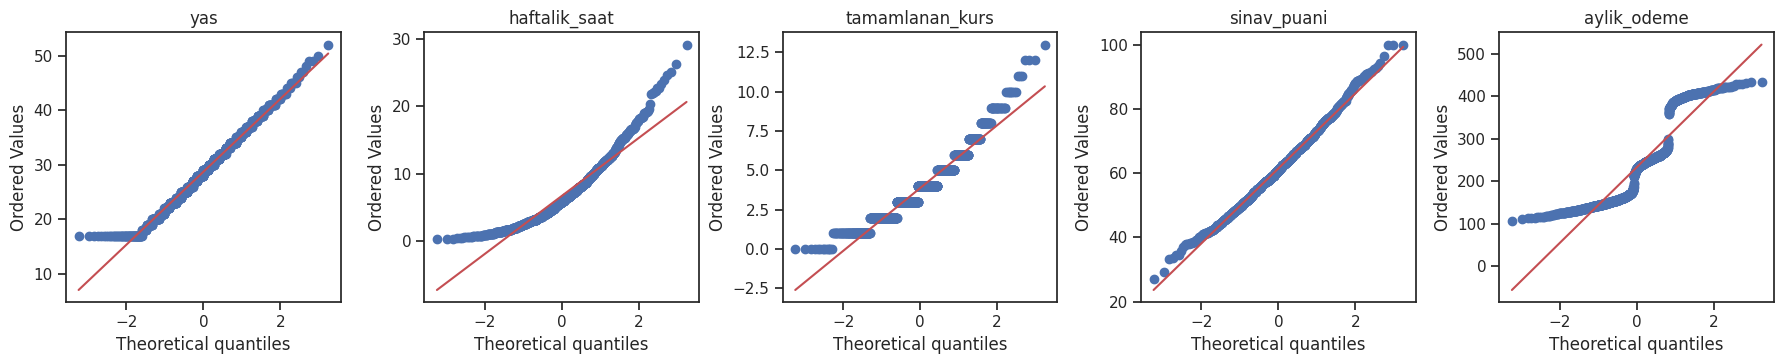

In [8]:
fig, axes = plt.subplots(1, len(sayisal), figsize=(18, 3.8))
for ax, col in zip(axes, sayisal):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. İki Grup Karşılaştırması
Soru: **Sertifika alanlar ile almayanların haftalık çalışma süresi farklı mı?**

Test seçimi:
1. **Levene** ile varyans eşitliği kontrolü
2. Normallik sağlanıyorsa **t-testi** (varyanslar eşit değilse Welch), sağlanmıyorsa **Mann-Whitney U**
3. Farkın büyüklüğü için **Cohen's d** (0.2 küçük, 0.5 orta, 0.8 büyük)

In [9]:
g_evet = df.loc[df["sertifika_aldi"] == 1, "haftalik_saat"].dropna()
g_hayir = df.loc[df["sertifika_aldi"] == 0, "haftalik_saat"].dropna()

_, p_levene = stats.levene(g_evet, g_hayir)
_, p_norm1 = stats.shapiro(g_evet)
_, p_norm2 = stats.shapiro(g_hayir)
print(f"Levene p = {p_levene:.4f}  → varyanslar {'eşit' if p_levene > 0.05 else 'eşit değil'}")
print(f"Normallik p: sertifikalı = {p_norm1:.4f}, sertifikasız = {p_norm2:.4f}")

t, p_t = stats.ttest_ind(g_evet, g_hayir, equal_var=p_levene > 0.05)
u, p_u = stats.mannwhitneyu(g_evet, g_hayir, alternative="two-sided")
print(f"\nt-testi       : t = {t:.3f}, p = {p_t:.2e}")
print(f"Mann-Whitney U: U = {u:.0f}, p = {p_u:.2e}")

ortak_std = np.sqrt(((len(g_evet) - 1) * g_evet.var() + (len(g_hayir) - 1) * g_hayir.var())
                    / (len(g_evet) + len(g_hayir) - 2))
print(f"Cohen's d = {(g_evet.mean() - g_hayir.mean()) / ortak_std:.2f}")

Levene p = 0.0000  → varyanslar eşit değil
Normallik p: sertifikalı = 0.0000, sertifikasız = 0.0000

t-testi       : t = 11.815, p = 2.46e-28
Mann-Whitney U: U = 200386, p = 1.25e-31
Cohen's d = 0.89


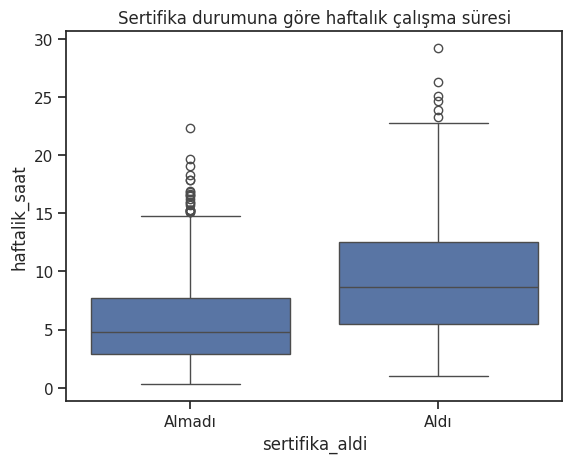

In [10]:
sns.boxplot(data=df, x="sertifika_aldi", y="haftalik_saat")
plt.xticks([0, 1], ["Almadı", "Aldı"])
plt.title("Sertifika durumuna göre haftalık çalışma süresi")
plt.show()

## 5. Çoklu Grup Karşılaştırması
Soru: **Paket tipine göre sınav puanı değişiyor mu?** (3 grup)
- **ANOVA** (parametrik) ve **Kruskal-Wallis** (parametrik olmayan)
- **Eta kare (η²)**: puandaki değişimin ne kadarı paket farkından geliyor (0.01 küçük, 0.06 orta, 0.14 büyük)
- ANOVA anlamlıysa hangi gruplar arasında fark olduğunu **Tukey HSD** ile buluyorum.

In [11]:
temiz = df.dropna(subset=["sinav_puani"])
gruplar = [g["sinav_puani"].to_numpy() for _, g in temiz.groupby("paket")]

f, p_anova = stats.f_oneway(*gruplar)
h, p_kw = stats.kruskal(*gruplar)
print(f"ANOVA         : F = {f:.2f}, p = {p_anova:.2e}")
print(f"Kruskal-Wallis: H = {h:.2f}, p = {p_kw:.2e}")

genel_ort = temiz["sinav_puani"].mean()
ss_arasi = sum(len(g) * (g.mean() - genel_ort) ** 2 for g in gruplar)
ss_toplam = ((temiz["sinav_puani"] - genel_ort) ** 2).sum()
print(f"η² = {ss_arasi / ss_toplam:.3f}")

ANOVA         : F = 47.88, p = 1.02e-20
Kruskal-Wallis: H = 91.45, p = 1.39e-20
η² = 0.075


In [12]:
print(pairwise_tukeyhsd(temiz["sinav_puani"], temiz["paket"], alpha=0.05))

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Plus    Pro   3.1045 0.0022  0.9445  5.2644   True
  Plus  Temel  -4.8255    0.0 -6.5735 -3.0774   True
   Pro  Temel  -7.9299    0.0 -9.9624 -5.8974   True
----------------------------------------------------


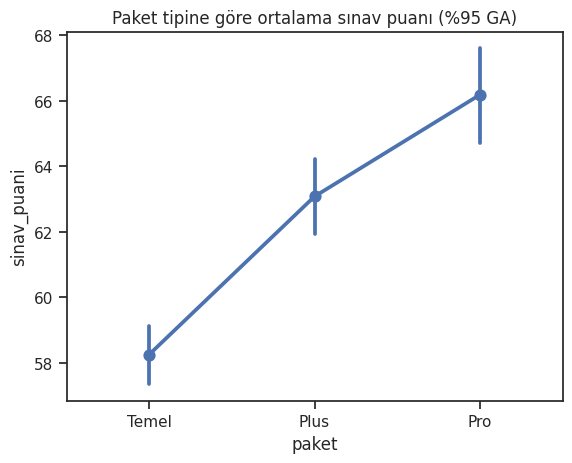

In [13]:
sns.pointplot(data=temiz, x="paket", y="sinav_puani", order=["Temel", "Plus", "Pro"], errorbar=("ci", 95))
plt.title("Paket tipine göre ortalama sınav puanı (%95 GA)")
plt.show()

## 6. Kategorik Değişkenler Arasındaki İlişki
Soru: **Paket tipi ile sertifika alma arasında ilişki var mı?**
- **Ki-kare bağımsızlık testi**: H0 = iki değişken bağımsız
- **Cramér's V**: ilişkinin gücü (0 = yok, 1 = tam). ~0.1 zayıf, ~0.3 orta, ~0.5+ güçlü

In [14]:
capraz = pd.crosstab(df["paket"], df["sertifika_aldi"])
chi2, p_chi, sd, beklenen = stats.chi2_contingency(capraz)

n = capraz.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(capraz.shape) - 1)))

print(capraz, end="\n\n")
print(f"χ² = {chi2:.2f}, sd = {sd}, p = {p_chi:.2e}")
print(f"Cramér's V = {cramers_v:.3f}")

sertifika_aldi    0    1
paket                   
Plus            270  122
Pro             145  100
Temel           443  120

χ² = 33.83, sd = 2, p = 4.52e-08
Cramér's V = 0.168


In [15]:
# kontrol: ilişki olmaması beklenen bir çift
capraz2 = pd.crosstab(df["cihaz"], df["sertifika_aldi"])
chi2_2, p_2, _, _ = stats.chi2_contingency(capraz2)
print(f"Cihaz - sertifika: χ² = {chi2_2:.2f}, p = {p_2:.3f}")

Cihaz - sertifika: χ² = 0.01, p = 0.928


## 7. Korelasyon Analizi
- **Pearson**: doğrusal ilişki, normallik varsayar.
- **Spearman**: sıralamaya dayalı, monoton ilişkiler ve çarpık veri için daha güvenli.
Korelasyon katsayısının yanında **p-değerlerini** de hesaplayıp anlamlı olmayanları maskeliyorum.

In [16]:
def korelasyon_ve_p(veri, yontem="pearson"):
    fonk = stats.pearsonr if yontem == "pearson" else stats.spearmanr
    cols = veri.columns
    r = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    p = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            ikili = veri[[a, b]].dropna()
            katsayi, p_deger = fonk(ikili[a], ikili[b])
            r.loc[a, b] = r.loc[b, a] = katsayi
            p.loc[a, b] = p.loc[b, a] = p_deger
    return r, p

r_pearson, p_pearson = korelasyon_ve_p(df[sayisal], "pearson")
r_spearman, _ = korelasyon_ve_p(df[sayisal], "spearman")

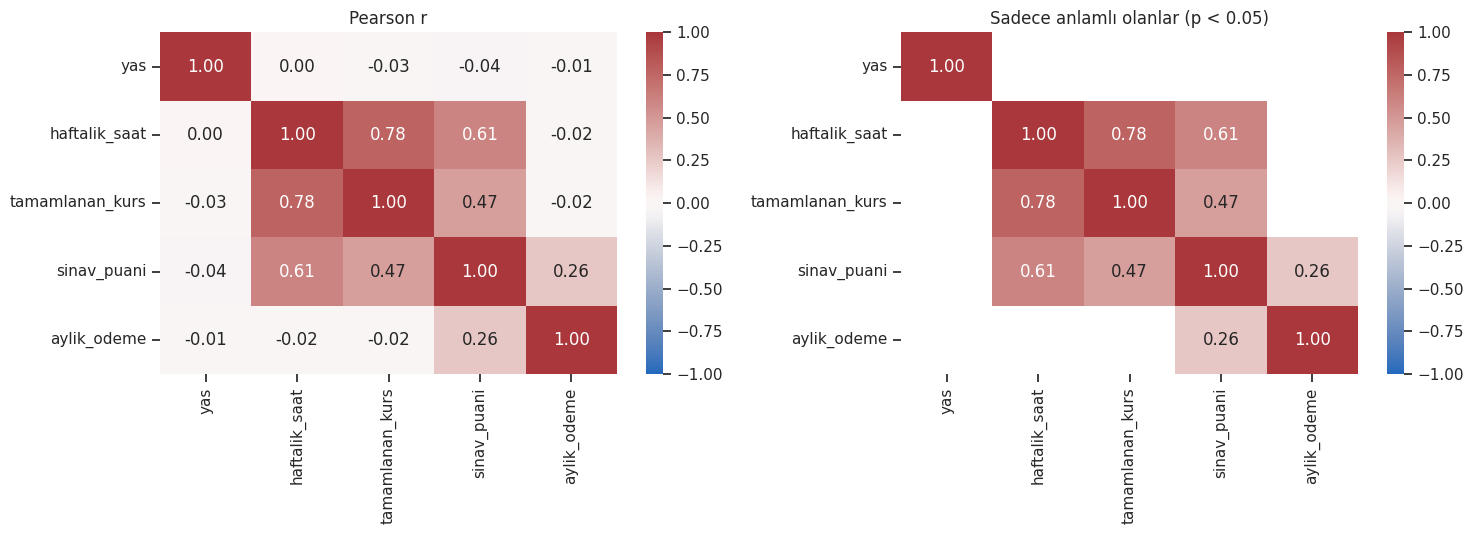

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(r_pearson, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson r")
sns.heatmap(r_pearson, mask=(p_pearson > 0.05), annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Sadece anlamlı olanlar (p < 0.05)")
plt.tight_layout()
plt.show()

In [18]:
# Pearson ile Spearman arasındaki farklar
(r_spearman - r_pearson).round(3)

,yas,haftalik_saat,tamamlanan_kurs,sinav_puani,aylik_odeme
yas,0.000,0.003,-0.013,0.002,-0.007
haftalik_saat,0.003,0.000,-0.053,-0.047,0.002
tamamlanan_kurs,-0.013,-0.053,0.000,-0.046,-0.011
sinav_puani,0.002,-0.047,-0.046,0.000,-0.003
aylik_odeme,-0.007,0.002,-0.011,-0.003,0.000


## 8. Çoklu Doğrusal Bağlantı (Multicollinearity) - VIF
Bağımsız değişkenler birbiriyle çok ilişkiliyse regresyon katsayıları kararsızlaşır.
- VIF < 5 → sorun yok
- 5–10 → dikkat
- VIF > 10 → ciddi sorun, değişkenlerden biri çıkarılmalı

Not: `add_constant` ile eklenen sabit terimin (0. sütun) VIF'ini yorumlamıyorum, döngüyü 1'den başlatıyorum.

In [19]:
aciklayicilar = ["yas", "haftalik_saat", "tamamlanan_kurs", "aylik_odeme"]
X_vif = sm.add_constant(df[aciklayicilar].dropna())

vif = pd.DataFrame({
    "degisken": aciklayicilar,
    "VIF": [variance_inflation_factor(X_vif.to_numpy(), i) for i in range(1, X_vif.shape[1])],
})
vif

,degisken,VIF
0,yas,1.002
1,haftalik_saat,2.570
2,tamamlanan_kurs,2.572
3,aylik_odeme,1.001


## 9. Keşifçi Regresyon (OLS)
Sınav puanını çalışma süresi, paket ve yaş ile açıklamaya çalışıyorum.
Formül arayüzünde `C(paket)` kategorik değişkeni otomatik olarak dummy değişkenlere çevirir. `Treatment('Temel')` ile referans grubu Temel paket yapıyorum; Plus/Pro katsayıları "Temel'e göre fark" olarak okunur.

In [20]:
model = smf.ols("sinav_puani ~ haftalik_saat + C(paket, Treatment('Temel')) + yas", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            sinav_puani   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     227.4
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          5.79e-143
Time:                        09:40:36   Log-Likelihood:                -4030.1
No. Observations:                1127   AIC:                             8070.
Df Residuals:                    1122   BIC:                             8095.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


**Okurken bakılacaklar:** R² (açıklanan varyans oranı), her katsayının işareti/büyüklüğü ve p-değeri (`P>|t|`).
Örn. `haftalik_saat` katsayısı ≈ 1.6 ise: diğerleri sabitken haftada 1 saat fazla çalışmak puanı ~1.6 artırıyor.

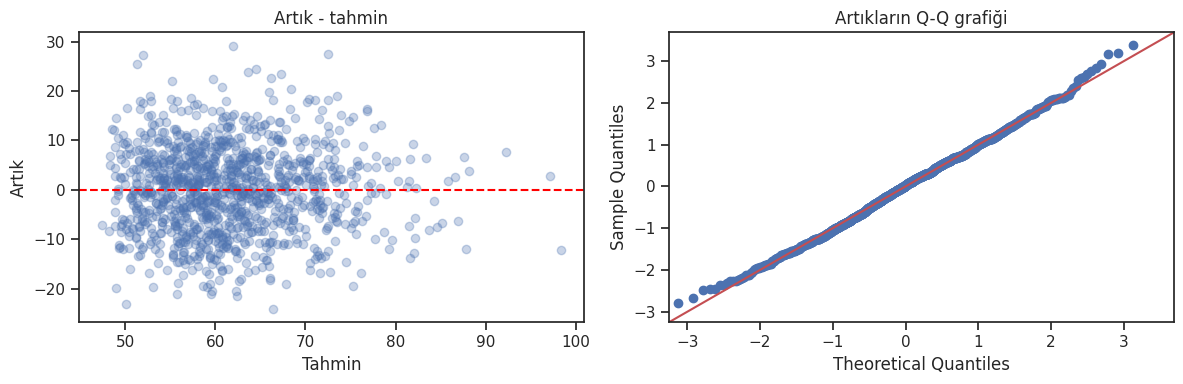

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.3)
axes[0].axhline(0, color="red", ls="--")
axes[0].set(xlabel="Tahmin", ylabel="Artık", title="Artık - tahmin")
sm.qqplot(model.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Artıkların Q-Q grafiği")
plt.tight_layout()
plt.show()

## 10. Temel Bileşenler Analizi (PCA)
Birbiriyle ilişkili sayısal değişkenleri, birbirinden bağımsız daha az sayıda bileşene indirger.
PCA ölçeğe duyarlı olduğu için önce **standartlaştırıyorum**.

In [22]:
pca_veri = df[sayisal].dropna()
X_std = StandardScaler().fit_transform(pca_veri)

pca = PCA().fit(X_std)
aciklanan = pca.explained_variance_ratio_
pd.DataFrame({
    "aciklanan_varyans": aciklanan,
    "kumulatif": aciklanan.cumsum(),
}, index=[f"PC{i+1}" for i in range(len(aciklanan))])

,aciklanan_varyans,kumulatif
PC1,0.452,0.452
PC2,0.220,0.672
PC3,0.199,0.871
PC4,0.091,0.962
PC5,0.038,1.000


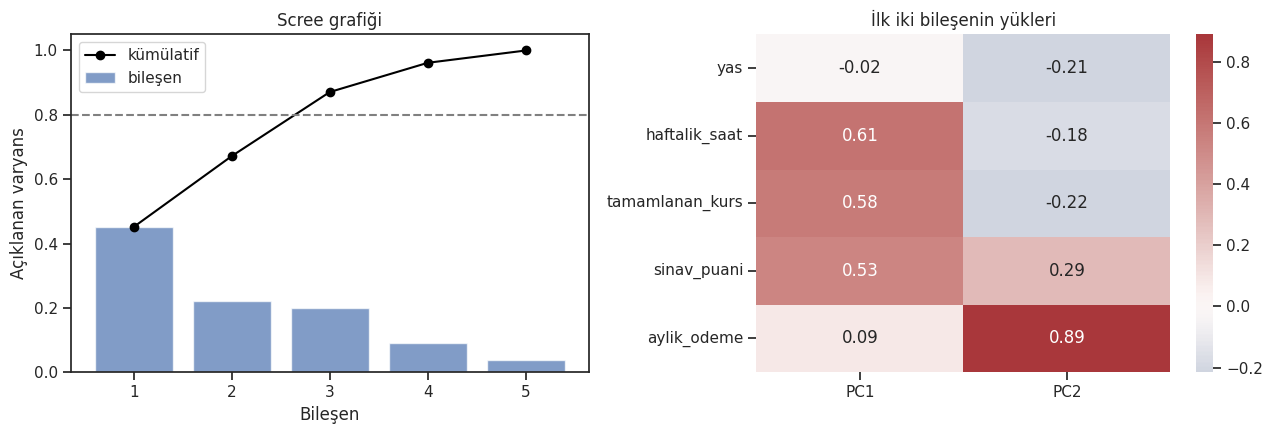

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = range(1, len(aciklanan) + 1)
axes[0].bar(x, aciklanan, alpha=0.7, label="bileşen")
axes[0].plot(x, aciklanan.cumsum(), "o-", color="black", label="kümülatif")
axes[0].axhline(0.8, ls="--", color="gray")
axes[0].set(xlabel="Bileşen", ylabel="Açıklanan varyans", title="Scree grafiği")
axes[0].legend()

yukler = pd.DataFrame(pca.components_[:2].T, index=sayisal, columns=["PC1", "PC2"])
sns.heatmap(yukler, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("İlk iki bileşenin yükleri")
plt.tight_layout()
plt.show()